# RevGuard — Exploratory Data Analysis

Before trusting an anomaly detector, we need to trust the data and the features it sees.
This notebook validates the transactions dataset and the six behavioral features that feed
the Isolation Forest.

**Data note:** the dataset is synthetic, produced by [`src/generate_dataset.py`](../src/generate_dataset.py)
(seeded, ~11k transactions across 1,500 users with realistic multi-order histories). A small
set of users follow injected fraud personas; their labels live in a separate file used only by
the [evaluation notebook](evaluation.ipynb) — the model itself is fully unsupervised.

**What we check here:**
1. Data quality — schema, missingness, date integrity
2. Transaction-level distributions
3. The six behavioral features: rationale and distributions
4. Feature correlations (redundancy check)
5. The resulting risk-score distribution and band thresholds

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from backend.ml.pipeline import FraudPipeline

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True,
                     'axes.titlesize': 11, 'axes.labelsize': 10})
BLUE, ORANGE, GRAY, RED = '#4C78A8', '#E8871E', '#9AA0A6', '#C4443C'
FEATURES = FraudPipeline.FEATURE_COLS

df = pd.read_csv(config.DATA_PATH, parse_dates=['purchase_date', 'return_date'])
print(f"{len(df):,} transactions | {df.user_id.nunique():,} users | "
      f"{df.purchase_date.min().date()} to {df.purchase_date.max().date()}")
df.head()

10,981 transactions | 1,500 users | 2023-01-09 to 2024-12-30


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,user_id,order_id,item_id,purchase_date,return_date,return_reason,refund_amount,payment_method,receipt_id
0,USER00000000,ORD00000000,PROD00000836,2024-02-29,NaT,Not Returned,326.99,PayPal,ORD00000000-PROD00000836
1,USER00000000,ORD00000001,PROD00001539,2024-04-11,2024-04-27,Defective,105.97,Credit Card,ORD00000001-PROD00001539
2,USER00000000,ORD00000002,PROD00002669,2024-06-11,NaT,Not Returned,99.73,PayPal,ORD00000002-PROD00002669
3,USER00000000,ORD00000003,PROD00001711,2024-08-08,NaT,Not Returned,1478.39,Credit Card,ORD00000003-PROD00001711
4,USER00000000,ORD00000004,PROD00000840,2024-09-25,NaT,Not Returned,48.65,PayPal,ORD00000004-PROD00000840


## 1. Data quality

`return_date` is missing exactly when `return_reason == "Not Returned"` — that is by design,
not a data problem. The integrity check that matters for our features: no return may predate
its purchase (a negative time-to-return would poison the `Avg Time-to-Return` feature).

In [2]:
summary = pd.DataFrame({'dtype': df.dtypes.astype(str),
                        'missing': df.isna().sum(),
                        'unique': df.nunique()})
display(summary)

returns = df[df.return_reason != 'Not Returned']
time_to_return = (returns.return_date - returns.purchase_date).dt.days
assert (time_to_return >= 0).all(), "found returns dated before their purchase"
assert not df.receipt_id.duplicated().any(), "duplicate receipts"

print(f"returned transactions: {len(returns):,} ({len(returns)/len(df):.1%} of all)")
print(f"time-to-return: min {time_to_return.min()}d, median {time_to_return.median():.0f}d, "
      f"max {time_to_return.max()}d — no negative values")

,dtype,missing,unique
user_id,object,0,1500
order_id,object,0,10981
item_id,object,0,4426
purchase_date,datetime64[ns],0,704
return_date,datetime64[ns],8242,627
return_reason,object,0,5
refund_amount,float64,0,9133
payment_method,object,0,4
receipt_id,object,0,10981


returned transactions: 2,739 (24.9% of all)
time-to-return: min 1d, median 14d, max 30d — no negative values


## 2. Transaction-level view

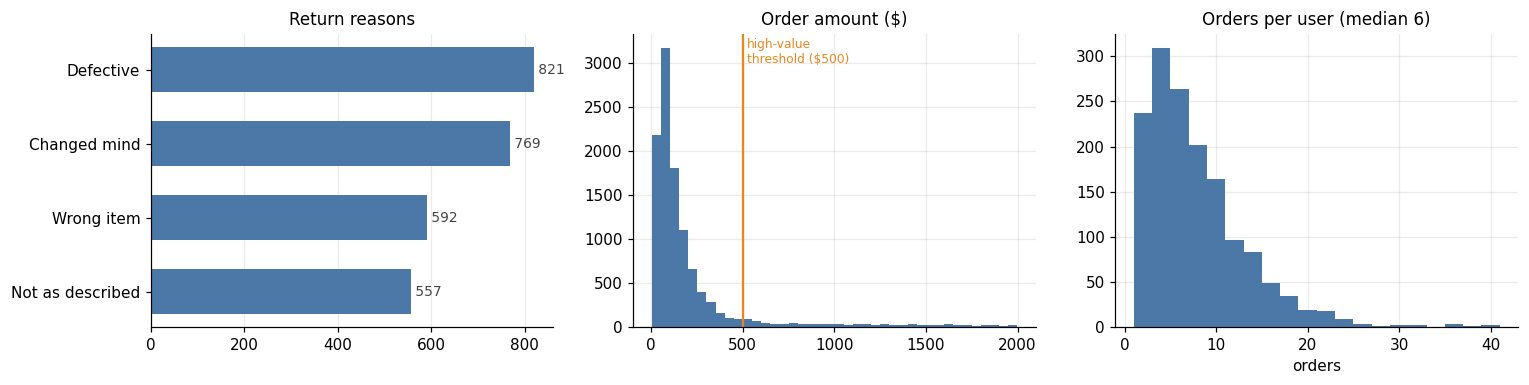

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

reason_counts = df.return_reason.value_counts().drop('Not Returned').sort_values()
axes[0].barh(reason_counts.index, reason_counts.values, color=BLUE, height=0.6)
for y, v in enumerate(reason_counts.values):
    axes[0].text(v, y, f' {v:,}', va='center', fontsize=9, color='#444')
axes[0].set_title('Return reasons')
axes[0].grid(axis='y', alpha=0)

axes[1].hist(df.refund_amount, bins=40, color=BLUE)
axes[1].axvline(config.HIGH_VALUE_ITEM_THRESHOLD, color=ORANGE, lw=1.5)
axes[1].text(config.HIGH_VALUE_ITEM_THRESHOLD * 1.05, axes[1].get_ylim()[1] * 0.9,
             f'high-value\nthreshold (${config.HIGH_VALUE_ITEM_THRESHOLD})', fontsize=8, color=ORANGE)
axes[1].set_title('Order amount ($)')

orders_per_user = df.groupby('user_id').size()
axes[2].hist(orders_per_user, bins=range(1, 42, 2), color=BLUE)
axes[2].set_title(f'Orders per user (median {orders_per_user.median():.0f})')
axes[2].set_xlabel('orders')

plt.tight_layout()
plt.show()

Prices are right-skewed with a long tail past the $500 high-value threshold, and users
have genuinely varied order histories — both are prerequisites for the behavioral features
below to carry signal.

## 3. Behavioral features

Each user who has made at least one return gets one row with six features
(engineered in `FraudPipeline.engineer_features`):

| Feature | Definition | Why it signals fraud |
|---|---|---|
| Return Frequency | returns ÷ orders old enough to be returnable (>30 days) | serial returners return most of what they buy |
| High-Value Item Ratio | share of returns above $500 | refund abusers target expensive items |
| Avg Time-to-Return | mean days between purchase and return | "wardrobing" shows unusually fast turnarounds |
| Reason Diversity | unique reasons ÷ total returns | fraudsters recycle the same excuse |
| Days Active | span between first and last purchase | fresh accounts with heavy returns are riskier |
| Top Reason Ratio | share of returns using the most common reason | a single dominant excuse is scripted behavior |

The 30-day eligibility cutoff in Return Frequency matters: counting a purchase made
yesterday in the denominator would dilute the rate for active users, since it has not
had a fair chance to be returned yet.

In [4]:
feats = FraudPipeline.engineer_features(df)
print(f"{len(feats):,} users with at least one return")
feats[FEATURES].describe().round(2)

962 users with at least one return


,Return Frequency,High-Value Item Ratio,Avg Time-to-Return,Reason Diversity,Days Active,Top Reason Ratio
count,962.00,962.00,962.00,962.00,962.00,962.00
mean,35.26,9.07,15.64,0.83,328.15,0.76
std,23.11,22.81,6.71,0.24,166.04,0.26
min,5.26,0.00,1.67,0.11,0.00,0.25
25%,18.18,0.00,11.00,0.67,199.00,0.50
50%,30.00,0.00,15.50,1.00,322.00,0.89
75%,50.00,0.00,20.00,1.00,450.00,1.00
max,100.00,100.00,30.00,1.00,713.00,1.00


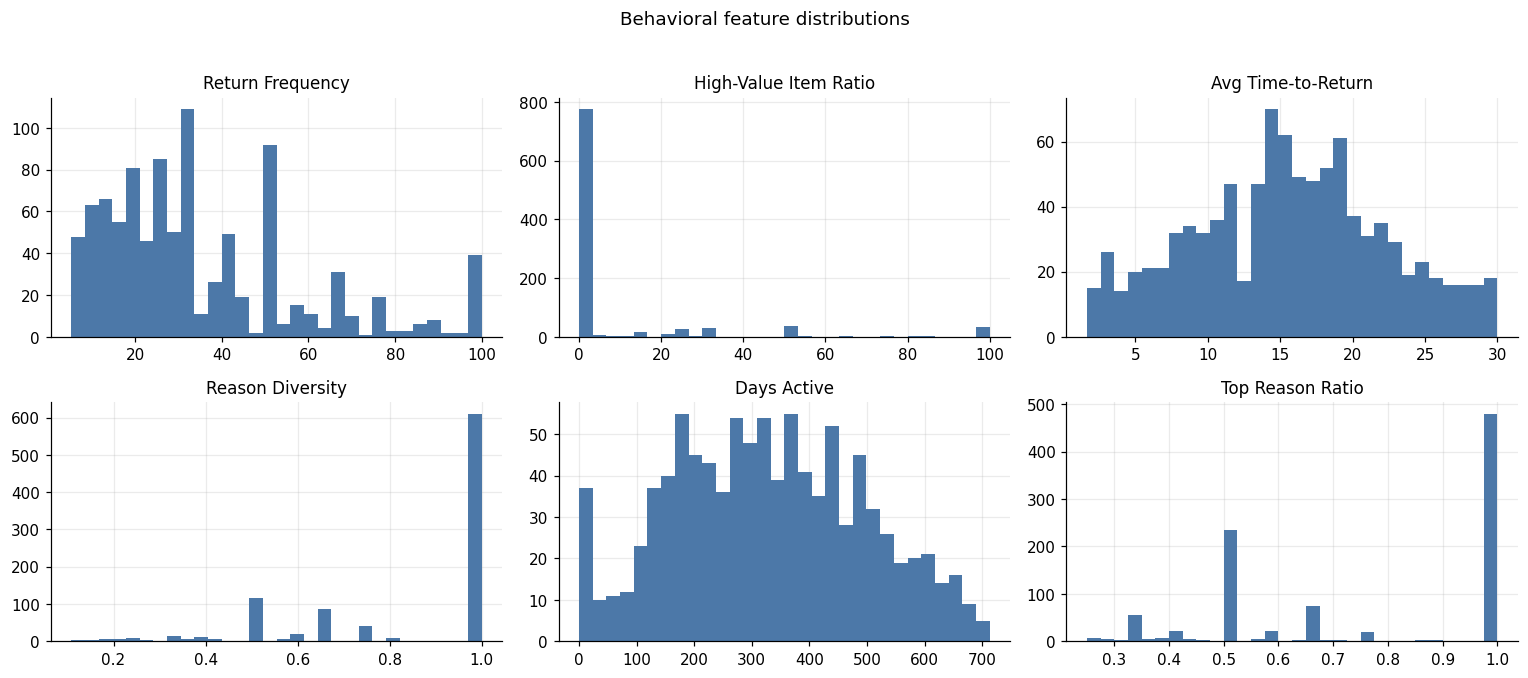

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, col in zip(axes.flat, FEATURES):
    ax.hist(feats[col], bins=30, color=BLUE)
    ax.set_title(col)
plt.suptitle('Behavioral feature distributions', y=1.02)
plt.tight_layout()
plt.show()

All six features vary across users (no degenerate constants), and several are visibly
long-tailed — Return Frequency and High-Value Item Ratio have small extreme groups sitting
far from the bulk of users, which is exactly the structure an Isolation Forest isolates well.

## 4. Feature correlations

A redundancy check: highly correlated features would double-count the same behavior in the
model and dilute SHAP attributions across duplicates.

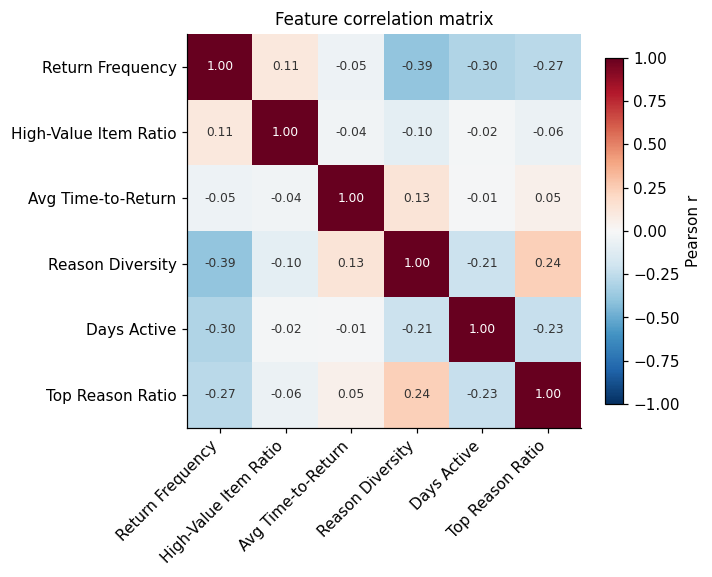

In [6]:
corr = feats[FEATURES].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=45, ha='right')
ax.set_yticks(range(len(FEATURES)), FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else '#333')
ax.grid(False)
fig.colorbar(im, shrink=0.8, label='Pearson r')
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

The one strong relationship is **Reason Diversity vs. Top Reason Ratio** — by construction
they move in opposite directions (one dominant excuse ⇒ low diversity). They are kept as a pair
deliberately: diversity is normalized by return count while the top-reason share is not, so they
separate different volumes of scripted behavior. Everything else is weakly correlated, so the
model sees six largely independent behavioral dimensions.

## 5. Risk-score distribution

Scores come from the trained production model (`models/user_features.pkl`): Isolation Forest
decision scores min-max scaled to 0–100, banded at Medium ≥ 41 and High ≥ 71.

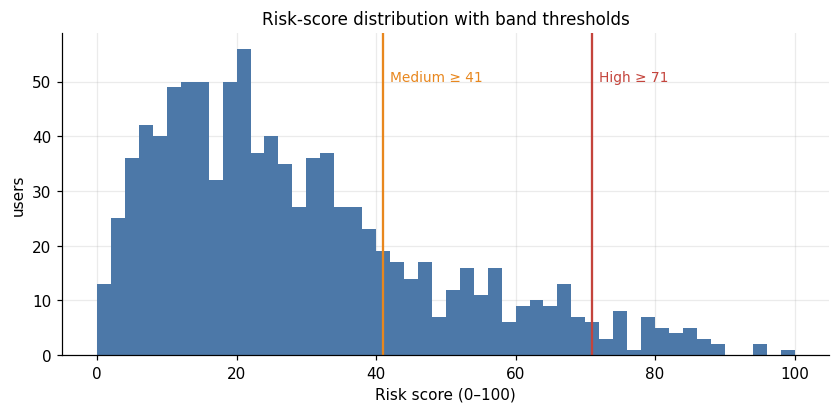

Risk Band
Low       741
Medium    179
High       42


In [7]:
uf = pd.read_pickle(config.USER_FEATURES_PATH)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(uf['Risk Score'], bins=50, color=BLUE)
for thr, name in [(config.MEDIUM_RISK_THRESHOLD, 'Medium'), (config.HIGH_RISK_THRESHOLD, 'High')]:
    ax.axvline(thr, color=RED if name == 'High' else ORANGE, lw=1.5)
    ax.text(thr + 1, ax.get_ylim()[1] * 0.85, f'{name} ≥ {thr}', fontsize=9,
            color=RED if name == 'High' else ORANGE)
ax.set_xlabel('Risk score (0–100)')
ax.set_ylabel('users')
ax.set_title('Risk-score distribution with band thresholds')
plt.show()
print(uf['Risk Band'].value_counts().to_string())

## Key takeaways

- The dataset passes integrity checks: no impossible dates, no duplicate receipts, and
  missingness only where it is structural.
- All six behavioral features are non-degenerate and mostly independent; the one strong
  correlation (Reason Diversity ↔ Top Reason Ratio) is understood and intentional.
- The risk-score distribution is right-skewed with a thin high-score tail — a small,
  investigable set of flagged users rather than a wall of alerts.
- Whether the flags are *correct* is the subject of [`evaluation.ipynb`](evaluation.ipynb),
  which scores the model against the generator's held-out fraud labels.